# Processo

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

rng = np.random.RandomState(2021)

class CSTR():

    def __init__(self):

                # Steady State Initial Conditions for the States
        self.Ca_ss = 0.87725294608097
        self.T_ss = 300
        self.x0 = np.empty(2)
        self.x0[0] = self.Ca_ss
        self.x0[1] = self.T_ss

        # Steady State Initial Condition
        self.u_ss = 274.3458
        # Feed Temperature (K)
        self.Tf = 350
        # Feed Concentration (mol/m^3)
        self.Caf = 1

        # Time Interval (min)
        self.t = np.linspace(0, 6, 361)

        # Store results for plotting
        self.Ca = np.ones(len(self.t)) * self.Ca_ss
        self.T = np.ones(len(self.t)) * self.T_ss
        self.u = np.ones(len(self.t)) * self.u_ss


        # storage for recording values
        self.op = np.ones(len(self.t))*self.u_ss  # controller output
        self.pv = np.zeros(len(self.t))  # process variable
        self.e = np.zeros(len(self.t))   # error
        self.ie = np.zeros(len(self.t))  # integral of the error
        self.dpv = np.zeros(len(self.t)) # derivative of the pv
        self.P = np.zeros(len(self.t))   # proportional
        self.I = np.zeros(len(self.t))   # integral
        self.D = np.zeros(len(self.t))   # derivative
        self.sp = np.zeros(len(self.t))  # set point

        self.sp[0:30] = self.T_ss
        self.sp[30:] = 320
        #self.sp[110:] = 330
        #self.sp[190:] = 340
        #self.sp[270:] = 350


        # Upper and Lower limits on OP
        self.op_hi = 350.0
        self.op_lo = 250.0

        self.pv[0] = self.T_ss

    def read(self):
         return self.T_ss, self.pv[1]

    def step(self, Kp, Ki, Kd, ts, te):

       # define CSTR model
        def cstr(x, t, u, Tf, Caf):
            # Inputs (3):
            # Temperature of cooling jacket (K)
            Tc = u
            # Tf = Feed Temperature (K)
            # Caf = Feed Concentration (mol/m^3)

            # States (2):
            # Concentration of A in CSTR (mol/m^3)
            Ca = x[0]
            # Temperature in CSTR (K)
            T = x[1]

            # Parameters:
            # Volumetric Flowrate (m^3/sec)
            q = 100
            # Volume of CSTR (m^3)
            V = 100
            # Density of A-B Mixture (kg/m^3)
            rho = 1000
            # Heat capacity of A-B Mixture (J/kg-K)
            Cp = 0.239
            # Heat of reaction for A->B (J/mol)
            mdelH = 5e4
            # E - Activation energy in the Arrhenius Equation (J/mol)
            # R - Universal Gas Constant = 8.31451 J/mol-K
            EoverR = 8750
            # Pre-exponential factor (1/sec)
            k0 = 7.2e10
            # U - Overall Heat Transfer Coefficient (W/m^2-K)
            # A - Area - this value is specific for the U calculation (m^2)
            UA = 5e4
            # reaction rate
            rA = k0*np.exp(-EoverR/T)*Ca

            # Calculate concentration derivative
            dCadt = q/V*(Caf - Ca) - rA
            # Calculate temperature derivative
            dTdt = q/V*(Tf - T) \
                    + mdelH/(rho*Cp)*rA \
                    + UA/V/rho/Cp*(Tc-T)

            # Return xdot:
            xdot = np.zeros(2)
            xdot[0] = dCadt
            xdot[1] = dTdt
            return xdot

        sumError = 0
        sat = False
        # loop through time steps
        for i in range(ts, te):

            delta_t = self.t[i+1] - self.t[i]
            self.e[i] = self.sp[i] - self.pv[i]
            sumError += abs(self.e[i])
            if i >= 1:  # calculate starting on second cycle
                self.dpv[i] = (self.pv[i]-self.pv[i-1])/delta_t
                self.ie[i] = self.ie[i-1] + self.e[i] * delta_t
            self.P[i] = Kp * self.e[i]
            self.I[i] = Ki * self.ie[i]
            self.D[i] = - Kd * self.dpv[i]
            self.op[i] = self.op[0] + self.P[i] + self.I[i] + self.D[i]
            if self.op[i] > self.op_hi:  # check upper limit
                sat = True
                self.op[i] = self.op_hi
                self.ie[i] = self.ie[i] - self.e[i] * delta_t # anti-reset windup
            if self.op[i] < self.op_lo:  # check lower limit
                sat = True
                self.op[i] = self.op_lo
                self.ie[i] = self.ie[i] - self.e[i] * delta_t # anti-reset windup
            self.ts = [self.t[i], self.t[i+1]]
            self.u[i+1] = self.op[i]
            self.y = odeint(cstr,self.x0,self.ts,args=(self.u[i+1],self.Tf,self.Caf))
            self.Ca[i+1] = self.y[-1][0]
            self.T[i+1] = self.y[-1][1]
            self.x0[0] = self.Ca[i+1]
            self.x0[1] = self.T[i+1]
            self.pv[i+1] = self.T[i+1]



        self.op[len(self.t)-1] = self.op[len(self.t)-2]
        self.ie[len(self.t)-1] = self.ie[len(self.t)-2]
        self.P[len(self.t)-1] = self.P[len(self.t)-2]
        self.I[len(self.t)-1] = self.I[len(self.t)-2]
        self.D[len(self.t)-1] = self.D[len(self.t)-2]


        reward = 1/sumError

        return (self.pv[ts], self.pv[te]), reward

    def reset(self):

                # Steady State Initial Conditions for the States
        self.Ca_ss = 0.87725294608097
        self.T_ss = 300
        self.x0 = np.empty(2)
        self.x0[0] = self.Ca_ss
        self.x0[1] = self.T_ss

        # Steady State Initial Condition
        self.u_ss = 274.3458
        # Feed Temperature (K)
        self.Tf = 350
        # Feed Concentration (mol/m^3)
        self.Caf = 1

        # Time Interval (min)
        self.t = np.linspace(0, 6, 361)

        # Store results for plotting
        self.Ca = np.ones(len(self.t)) * self.Ca_ss
        self.T = np.ones(len(self.t)) * self.T_ss
        self.u = np.ones(len(self.t)) * self.u_ss


        # storage for recording values
        self.op = np.ones(len(self.t))*self.u_ss  # controller output
        self.pv = np.zeros(len(self.t))  # process variable
        self.e = np.zeros(len(self.t))   # error
        self.ie = np.zeros(len(self.t))  # integral of the error
        self.dpv = np.zeros(len(self.t)) # derivative of the pv
        self.P = np.zeros(len(self.t))   # proportional
        self.I = np.zeros(len(self.t))   # integral
        self.D = np.zeros(len(self.t))   # derivative
        self.sp = np.zeros(len(self.t))  # set point

        self.sp[0:30] = self.T_ss
        self.sp[30:] = 320
        #self.sp[110:] = 330
        #self.sp[190:] = 340
        #self.sp[270:] = 350


        # Upper and Lower limits on OP
        self.op_hi = 350.0
        self.op_lo = 250.0

        self.pv[0] = self.T_ss


    def fig(self):

        plt.figure(1)
        plt.rcParams.update({'font.size': 12})
        fig, ax = plt.subplots(nrows = 1, ncols = 1,figsize = [25, 10])

        plt.subplot(2,1,1)
        plt.plot(self.t,self.T,'k',linewidth=3,label='Reactor Temperature (PV)')
        plt.plot(self.t,self.sp,'b--',linewidth=2,label='Set Point')
        plt.ylabel('T (K)')
        plt.xlabel('Time (min)')
        plt.legend(loc='best')


        plt.subplot(2,1,2)
        plt.plot(self.t,self.op,'r--',linewidth=3,label='Controller Output (MV)')
        plt.legend(loc='best')
        plt.ylabel('Output')

        plt.show()



# Run 2000

A saída de streaming foi truncada nas últimas 5000 linhas.
Step:  500  Reward:  15.751668091327826   Actions:  {0: (np.float64(8.557905984089683), np.float64(13.7727701721551), np.float64(0.2442989452298414)), 1: (np.float64(14.232244235852058), np.float64(9.76371547841506), np.float64(0.022499203944223296)), 2: (np.float64(11.118607765610927), np.float64(11.526187382962595), np.float64(0.10962745825802385)), 3: (np.float64(11.038340714333415), np.float64(11.46487169706074), np.float64(0.10955040997864814))}
## valor interessante ####
Step:  501  Reward:  8.962046603106613   Actions:  {0: (np.float64(9.055749895126205), np.float64(13.659576120453435), np.float64(0.06306469870868314)), 1: (np.float64(14.225261973346864), np.float64(10.081599103031467), np.float64(0.04028203471294285)), 2: (np.float64(11.190809322143489), np.float64(11.478446856057772), np.float64(0.011765183855245642)), 3: (np.float64(11.276316002888777), np.float64(11.556074230639389), np.float64(0.011731638149781627))

<Figure size 640x480 with 0 Axes>

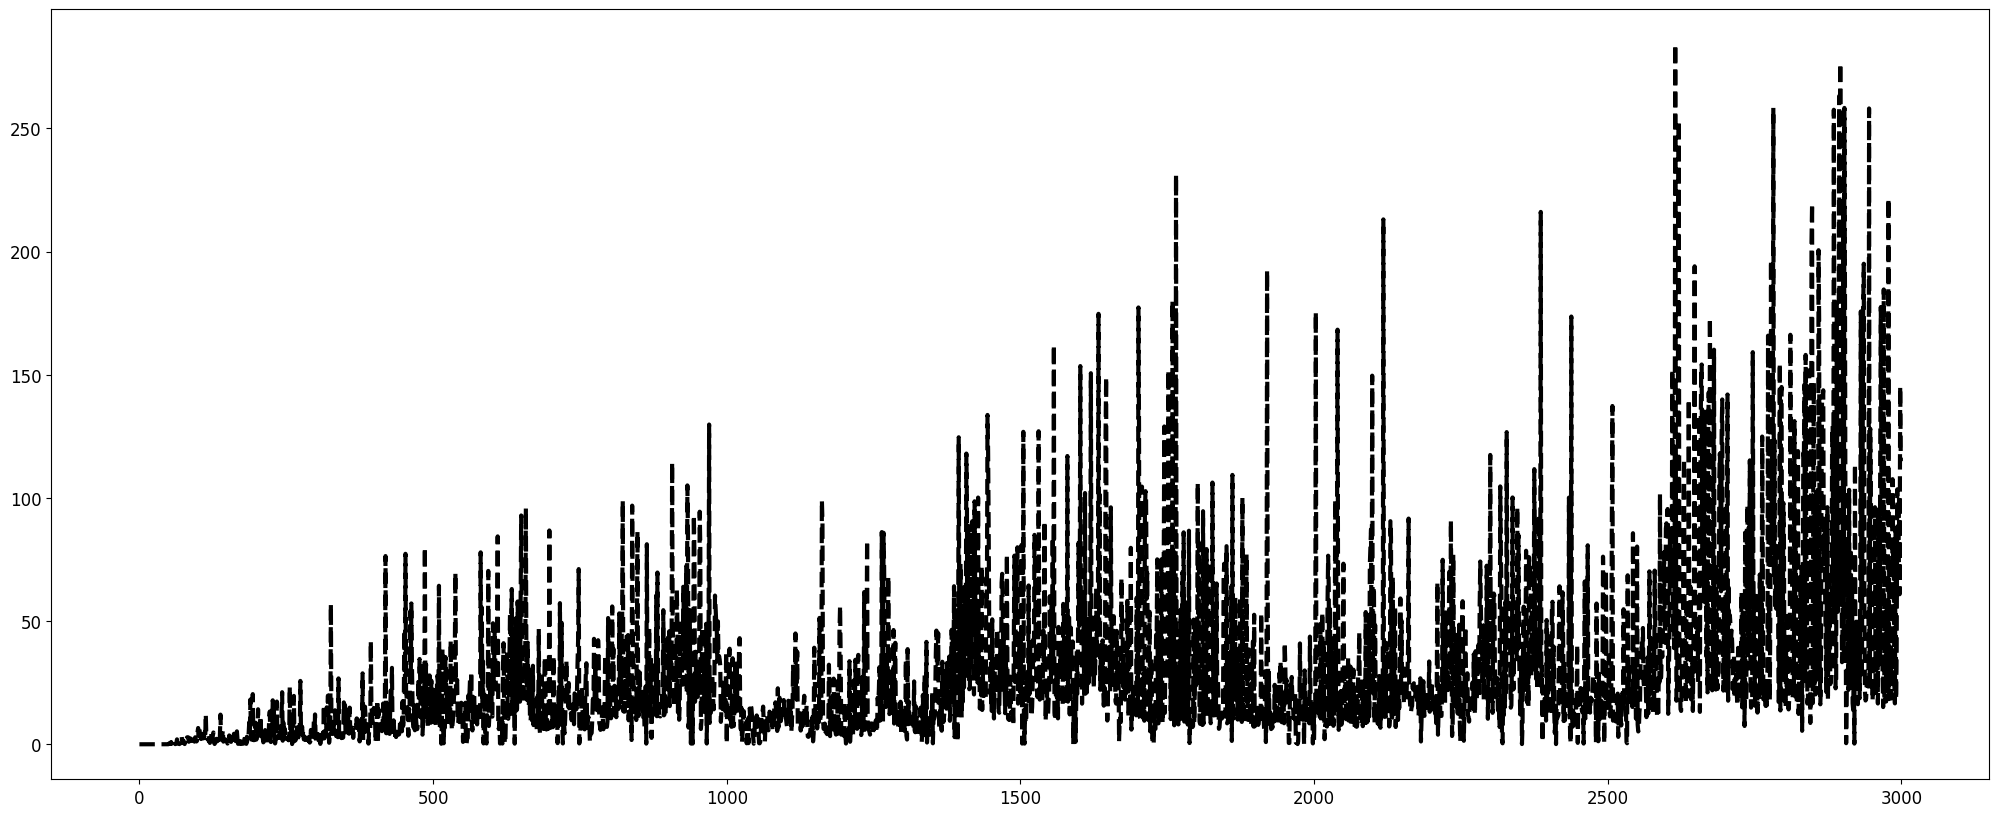

In [ ]:
# ARS

# Configuração dos hiperparâmetros
class Hp():
    def __init__(self):
        self.nb_steps = 3000
        self.episode_lenght = 4
        self.learning_rate = 0.4
        self.nb_directions = 16
        self.nb_best_directions = 12
        assert self.nb_best_directions <= self.nb_directions
        self.noise = 0.3
        self.seed = 4



# Normalização dos estados
class Normalizer():
    def __init__(self, nb_inputs):
        self.n = np.zeros(nb_inputs)
        self.mean = np.zeros(nb_inputs)
        self.mean_diff = np.zeros(nb_inputs)
        self.var = np.zeros(nb_inputs)

    def observe(self, x):

        self.n += 1.
        last_mean = self.mean.copy()
        self.mean += (x - self.mean) / self.n
        self.mean_diff += (x - last_mean) * (x - self.mean)
        self.var = (self.mean_diff / self.n).clip(min = 1e-2) # 0.001

    def normalize(self, inputs):
        obs_mean = self.mean
        obs_std = np.sqrt(self.var)
        return (inputs - obs_mean) / obs_std

# Construção da inteligência artificial

class Policy():
    def __init__(self, input_size, output_size):
        self.theta = np.zeros((output_size, input_size))

    def evaluate(self, input, delta = None, direction = None):
        if direction is None:
            return self.theta.dot(input)

        elif direction == 'positive':
            return (self.theta + hp.noise * delta).dot(input)

        else:
            return (self.theta - hp.noise * delta).dot(input)


    def sample_deltas(self):
        return [rng.randn(*self.theta.shape) for _ in range(hp.nb_directions)]

    # rollout [recompensa positiva, recompensa negativa, pertubução (delta)]
    # sigma_r -> desvio padrão da recompensa
    def update(self, rollouts, sigma_r):
        step = np.zeros(self.theta.shape)
        for r_pos, r_neg, d in rollouts:
            step += (r_pos - r_neg) * d

        self.theta += hp.learning_rate / (hp.nb_best_directions * sigma_r) * step



# Explora a política em uma direção específica e dentro de um episódio
def explore(env, normalizer, policy, direction = None, delta = None):

    env.reset()
    state = env.read()                  # rese
    #print('state: ', state)
    num_plays = 0
    sum_rewards = 0
    t = [0, 110, 190, 270, 360]
    actions = {}

    while num_plays < hp.episode_lenght:
        normalizer.observe(state)
        state = normalizer.normalize(state)
        action = policy.evaluate(state, delta, direction)

        #action[0] = 4.61730615181
        #action[1] = 40.43861496

        state, reward = env.step(abs(action[0]), abs(action[1]), abs(action[2]), t[num_plays], t[num_plays+1])
        #if num_plays == 0:
        #    env.fig()
        #print('state: ', state, 'Kp: ', action[0], 'Ki: ', action[1], "Rew: ", reward)
        #reward = max(min(reward, 1), -1)


        sum_rewards += reward
        actions[num_plays] = abs(action[0]), abs(action[1]), abs(action[2])
        num_plays += 1

    return sum_rewards, actions


# Treinamento da inteligência artificial
def train(env, policy, normalizer, hp):

    Control = {}
    Rws = np.zeros(hp.nb_steps)

    for step in range(hp.nb_steps):
        # Inicialização das perturbações (deltas) e as recompensas positivas e negativas
        deltas = policy.sample_deltas()
        positive_rewards = [0] * hp.nb_directions
        negative_rewards = [0] * hp.nb_directions

        # Obtendo as recompensas das direções positivas
        for k in range(hp.nb_directions):
            positive_rewards[k], actions = explore(env, normalizer, policy, direction = 'positive', delta = deltas[k])
            #print('positive: ', positive_rewards)

        # Obtendo as recompensas das direções negativas
        for k in range(hp.nb_directions):
            negative_rewards[k], actions = explore(env, normalizer, policy, direction = 'negative', delta = deltas[k])
            #print('negative: ', negative_rewards)

        # Obtendo todas as recompensas positivas e negativas para computar o desvio padrão dessas recompensas
        all_rewards = np.array(positive_rewards + negative_rewards)
        sigma_r = all_rewards.std().clip(min = 1e-2) # 0.001

        # Ordenação dos rollouts e seleção das melhores direções
        scores = {k: max(r_pos, r_neg) for k, (r_pos, r_neg) in enumerate(zip(positive_rewards, negative_rewards))}
        order = sorted(scores.keys(), key = lambda x: scores[x], reverse = True)[:hp.nb_best_directions]
        rollouts = [(positive_rewards[k], negative_rewards[k], deltas[k]) for k in order]

        # Atualização da política
        policy.update(rollouts, sigma_r)

        # Impressão da recompensa final depois da atualização
        reward_evaluation, actions = explore(env, normalizer, policy)
        print('Step: ', step, ' Reward: ', reward_evaluation, '  Actions: ', actions)
        #print('Step: ', step, ' Reward: ', reward_evaluation)
        if reward_evaluation > 0.03484710268240727:
            print('## valor interessante ####')
        Control[step] = actions
        Rws[step] = reward_evaluation


    return Control, Rws


# Execução do código principal

env = CSTR()
hp = Hp()
nb_inputs = 2
nb_outputs = 3
policy = Policy(nb_inputs, nb_outputs)
normalizer = Normalizer(nb_inputs)

Control, Rws = train(env, policy, normalizer, hp)



# grafico

plt.figure()
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(nrows = 1, ncols = 1,figsize = [25, 10])
plt.plot(Rws, 'k--', lw=3)



reward ARS:  407.2209813155214 Erro ARS:  122.50925313388622
reward    645.7358696432441 Erro:  136.55859075794842


Text(0, 0.5, 'Output')

<Figure size 640x480 with 0 Axes>

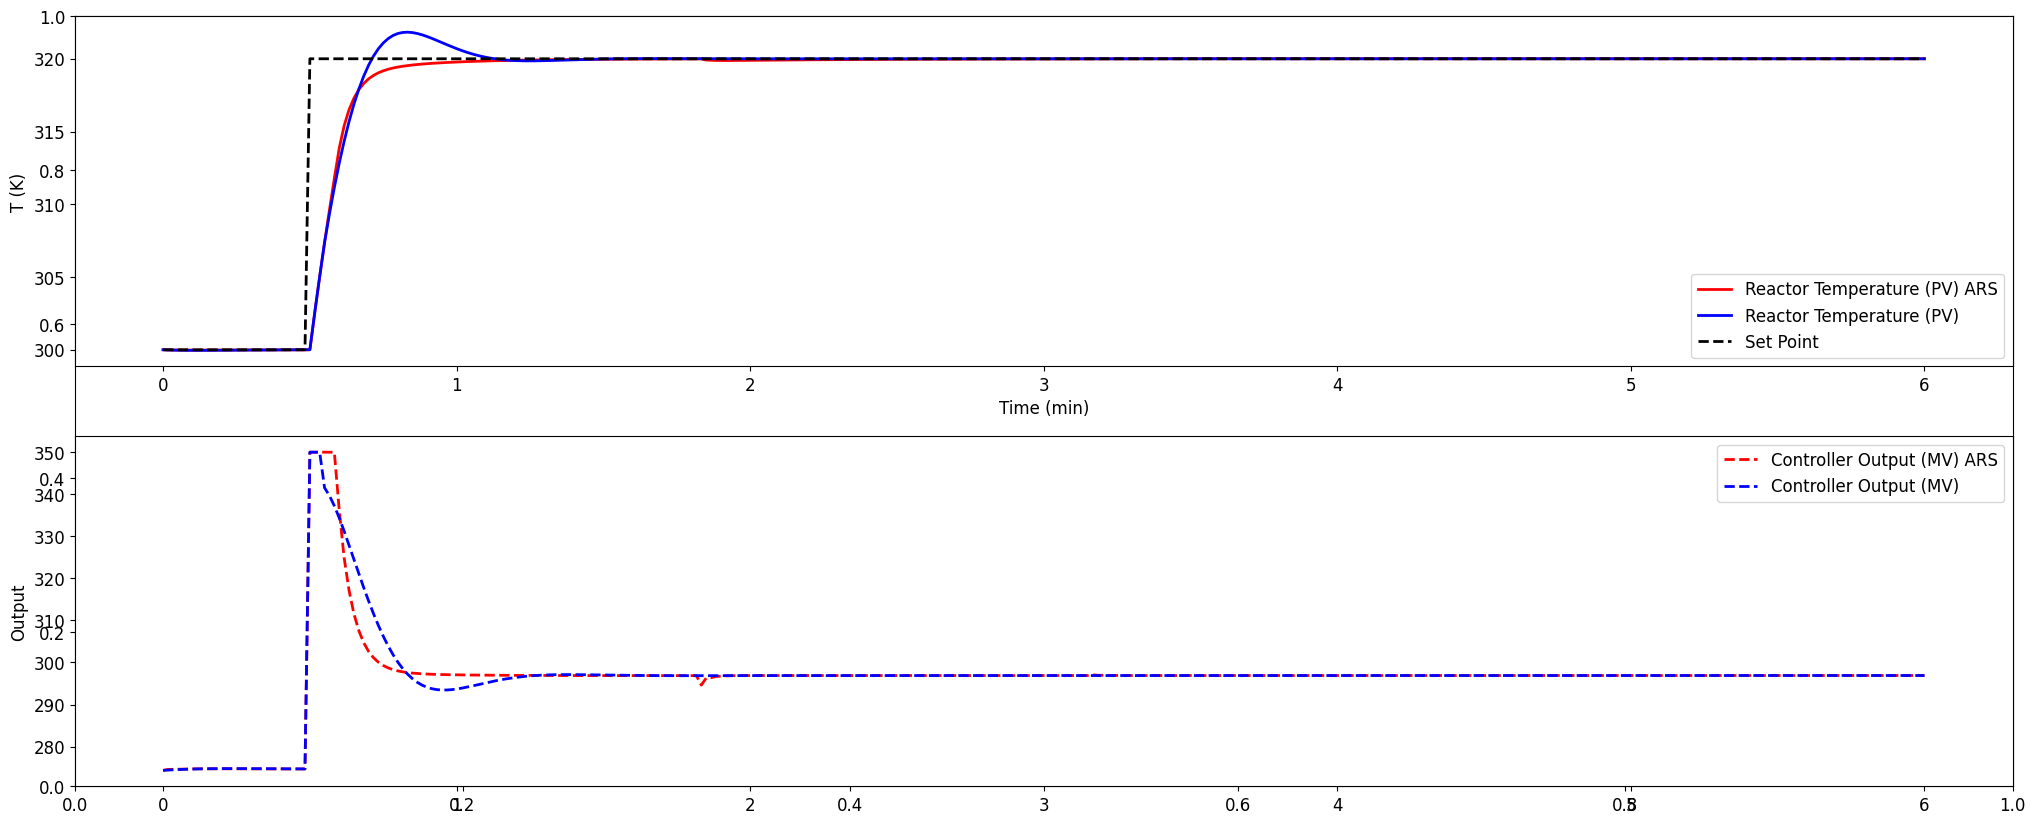

In [ ]:
env = CSTR()
envDefaut = CSTR()


t = [0, 110, 190, 270, 360]



actionKp = [11.063398292411435, 16.643393975217872, 13.148478450597251, 13.14873006819932]

actionKi = [38.64438095433241, 34.65442424480993, 34.97003155136577, 34.971136403302324]

actionKd = [0.08260778876288008, 0.07402129758392513, 0.07472656562072931, 0.07472892794917059]


sumRewardARS = 0
sumErroARS = 0
sumReward = 0
sumErro = 0

for i in range(4):
    state, rewardARS = env.step(actionKp[i], actionKi[i], actionKd[i], t[i], t[i+1])
    sumRewardARS += rewardARS
    sumErroARS += 1/rewardARS

    state, reward = envDefaut.step(4.61730615181, 40.43861496, 0, t[i], t[i+1])
    sumReward += reward
    sumErro += 1/reward

print('reward ARS: ', sumRewardARS, 'Erro ARS: ', sumErroARS)
print('reward   ', sumReward, 'Erro: ', sumErro)


plt.figure(1)
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [25, 10])

plt.subplot(2,1,1)
plt.plot(env.t, env.T, 'r', linewidth = 2,label = 'Reactor Temperature (PV) ARS')
plt.plot(envDefaut.t, envDefaut.T, 'b', linewidth = 2, label = 'Reactor Temperature (PV)')
plt.plot(env.t, env.sp, 'k--', linewidth = 2, label = 'Set Point')
plt.ylabel('T (K)')
plt.xlabel('Time (min)')
plt.legend(loc = 'best')


plt.subplot(2,1,2)
plt.plot(env.t, env.op, 'r--', linewidth = 2, label = 'Controller Output (MV) ARS')
plt.plot(envDefaut.t, envDefaut.op, 'b--', linewidth = 2, label='Controller Output (MV)')
plt.legend(loc = 'best')
plt.ylabel('Output')

#Teste com RK4

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.RandomState(2021)

class CSTR():

    def __init__(self):

        self.Ca_ss = 0.87725294608097
        self.T_ss = 300

        self.x0 = np.array([self.Ca_ss, self.T_ss])

        self.u_ss = 274.3458
        self.Tf = 350
        self.Caf = 1

        self.t = np.linspace(0, 6, 361)

        self.Ca = np.ones(len(self.t)) * self.Ca_ss
        self.T = np.ones(len(self.t)) * self.T_ss
        self.u = np.ones(len(self.t)) * self.u_ss

        self.op = np.ones(len(self.t))*self.u_ss
        self.pv = np.zeros(len(self.t))
        self.e = np.zeros(len(self.t))
        self.ie = np.zeros(len(self.t))
        self.dpv = np.zeros(len(self.t))
        self.P = np.zeros(len(self.t))
        self.I = np.zeros(len(self.t))
        self.D = np.zeros(len(self.t))
        self.sp = np.zeros(len(self.t))

        self.sp[0:30] = self.T_ss
        self.sp[30:] = 320

        self.op_hi = 350.0
        self.op_lo = 250.0

        self.pv[0] = self.T_ss

    # CSTR model
    def cstr(self, x, u):

        Ca = x[0]
        T = x[1]

        q = 100
        V = 100
        rho = 1000
        Cp = 0.239
        mdelH = 5e4
        EoverR = 8750
        k0 = 7.2e10
        UA = 5e4

        rA = k0*np.exp(-EoverR/T)*Ca

        dCadt = q/V*(self.Caf - Ca) - rA
        dTdt = q/V*(self.Tf - T) \
            + mdelH/(rho*Cp)*rA \
            + UA/V/rho/Cp*(u-T)

        return np.array([dCadt, dTdt])

    # RK4 integrator
    def rk4(self, x, u, dt):

        k1 = self.cstr(x, u)
        k2 = self.cstr(x + dt/2*k1, u)
        k3 = self.cstr(x + dt/2*k2, u)
        k4 = self.cstr(x + dt*k3, u)

        return x + dt/6*(k1 + 2*k2 + 2*k3 + k4)
    def read(self):
         return self.T_ss, self.pv[1]

    def step(self, Kp, Ki, Kd, ts, te):

        sumError = 0

        for i in range(ts, te):

            dt = self.t[i+1] - self.t[i]

            self.e[i] = self.sp[i] - self.pv[i]
            sumError += abs(self.e[i])

            if i >= 1:
                self.dpv[i] = (self.pv[i]-self.pv[i-1])/dt
                self.ie[i] = self.ie[i-1] + self.e[i]*dt

            self.P[i] = Kp * self.e[i]
            self.I[i] = Ki * self.ie[i]
            self.D[i] = -Kd * self.dpv[i]

            self.op[i] = self.op[0] + self.P[i] + self.I[i] + self.D[i]

            if self.op[i] > self.op_hi:
                self.op[i] = self.op_hi
                self.ie[i] -= self.e[i]*dt

            if self.op[i] < self.op_lo:
                self.op[i] = self.op_lo
                self.ie[i] -= self.e[i]*dt

            self.u[i+1] = self.op[i]

            # RK4 integration
            self.x0 = self.rk4(self.x0, self.u[i+1], dt)

            self.Ca[i+1] = self.x0[0]
            self.T[i+1] = self.x0[1]

            self.pv[i+1] = self.T[i+1]

        reward = 1/sumError

        return (self.pv[ts], self.pv[te]), reward

    def reset(self):

        self.__init__()

    def fig(self):

        plt.figure(figsize=(20,10))

        plt.subplot(2,1,1)
        plt.plot(self.t,self.T,'k',linewidth=3,label='Reactor Temperature')
        plt.plot(self.t,self.sp,'b--',linewidth=2,label='Set Point')
        plt.ylabel('T (K)')
        plt.xlabel('Time (min)')
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(self.t,self.op,'r--',linewidth=3,label='Controller Output')
        plt.ylabel('Output')
        plt.legend()

        plt.show()

In [ ]:
# ===== MELHORES RECOMPENSAS =====

best_reward = np.max(Rws)
best_step = np.argmax(Rws)

print("\n===== MELHOR RESULTADO =====")
print("Melhor recompensa:", best_reward)
print("Encontrada na iteração:", best_step)
print("Ações (PID):", Control[best_step])



===== MELHOR RESULTADO =====
Melhor recompensa: 284.1726568091061
Encontrada na iteração: 2615
Ações (PID): {0: (np.float64(11.77509102751386), np.float64(25.975037335000337), np.float64(0.1492706454329574)), 1: (np.float64(24.778950245320672), np.float64(20.468570281836147), np.float64(0.16228144013798979)), 2: (np.float64(17.397101492223733), np.float64(22.298490839011144), np.float64(0.14914089329217314)), 3: (np.float64(17.397144914404883), np.float64(22.30287734570155), np.float64(0.14916049754124197))}


#Teste

reward ARS:  284.1726568091061 Erro ARS:  144.40758861328828
reward    645.9008967092485 Erro:  136.55836622124184


Text(0, 0.5, 'Output')

<Figure size 640x480 with 0 Axes>

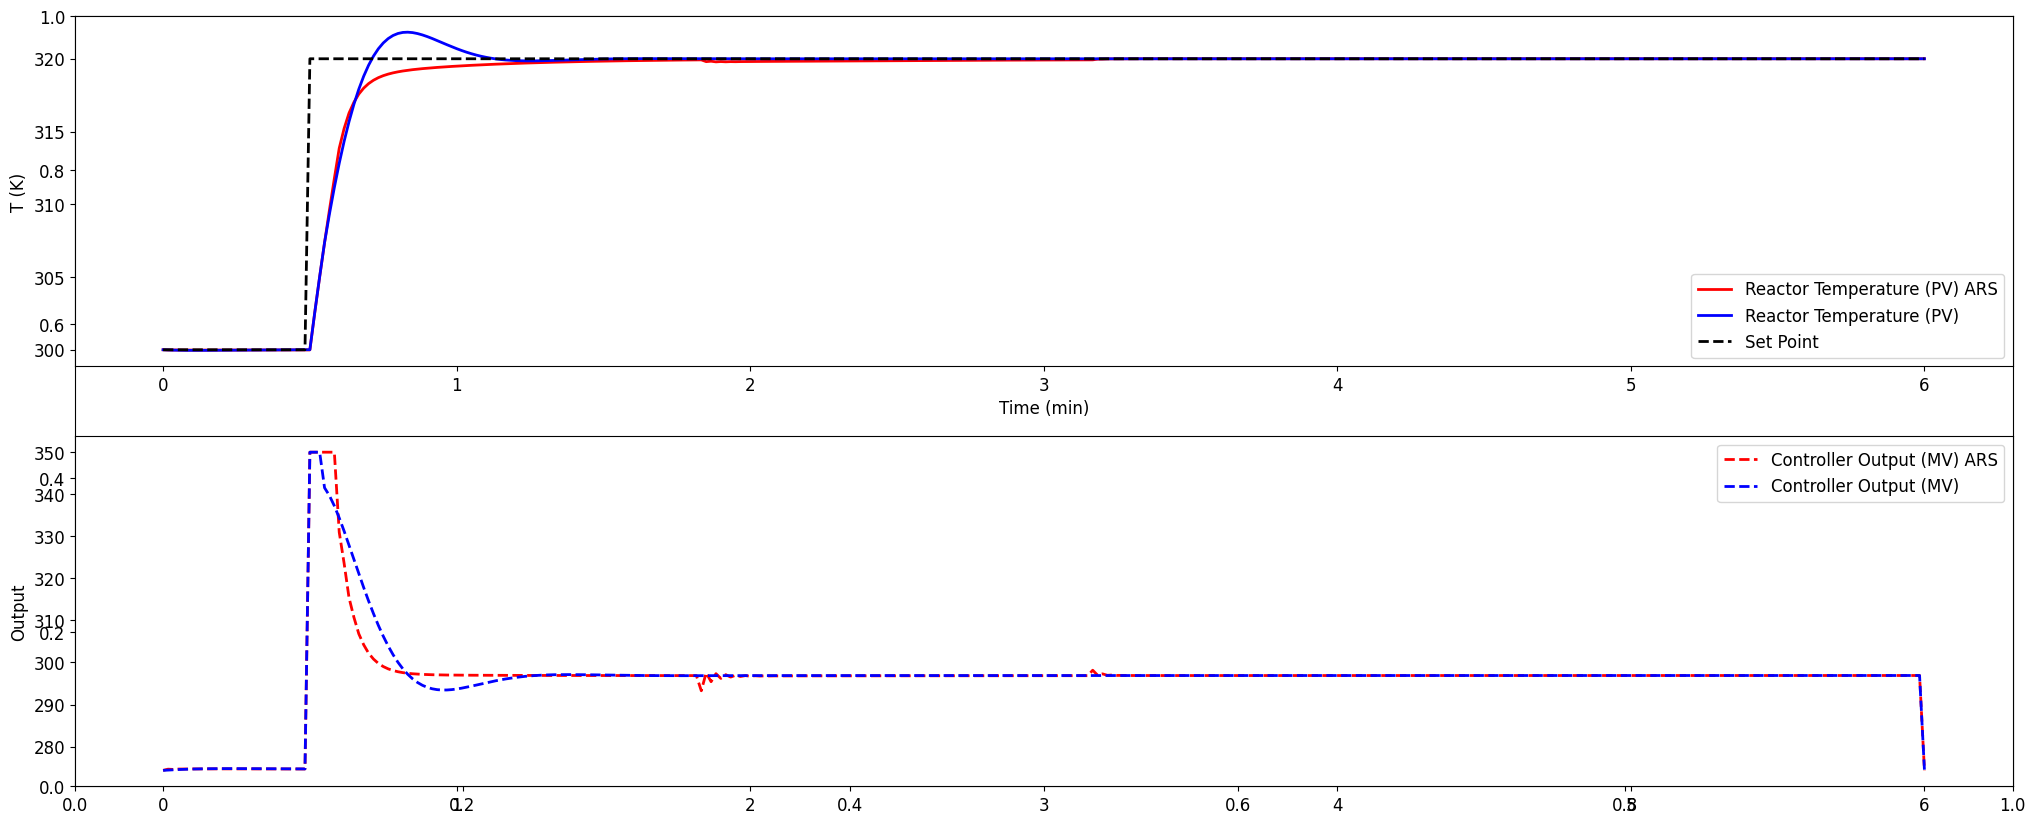

In [ ]:
env = CSTR()
envDefaut = CSTR()

t = [0, 110, 190, 270, 360]

actionKp = [
11.77509102751386,
24.778950245320672,
17.397101492223733,
17.397144914404883
]

actionKi = [
25.975037335000337,
20.468570281836147,
22.298490839011144,
22.30287734570155
]

actionKd = [
0.1492706454329574,
0.16228144013798979,
0.14914089329217314,
0.14916049754124197
]



sumRewardARS = 0
sumErroARS = 0
sumReward = 0
sumErro = 0

for i in range(4):
    state, rewardARS = env.step(actionKp[i], actionKi[i], actionKd[i], t[i], t[i+1])
    sumRewardARS += rewardARS
    sumErroARS += 1/rewardARS

    state, reward = envDefaut.step(4.61730615181, 40.43861496, 0, t[i], t[i+1])
    sumReward += reward
    sumErro += 1/reward

print('reward ARS: ', sumRewardARS, 'Erro ARS: ', sumErroARS)
print('reward   ', sumReward, 'Erro: ', sumErro)


plt.figure(1)
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [25, 10])

plt.subplot(2,1,1)
plt.plot(env.t, env.T, 'r', linewidth = 2,label = 'Reactor Temperature (PV) ARS')
plt.plot(envDefaut.t, envDefaut.T, 'b', linewidth = 2, label = 'Reactor Temperature (PV)')
plt.plot(env.t, env.sp, 'k--', linewidth = 2, label = 'Set Point')
plt.ylabel('T (K)')
plt.xlabel('Time (min)')
plt.legend(loc = 'best')


plt.subplot(2,1,2)
plt.plot(env.t, env.op, 'r--', linewidth = 2, label = 'Controller Output (MV) ARS')
plt.plot(envDefaut.t, envDefaut.op, 'b--', linewidth = 2, label='Controller Output (MV)')
plt.legend(loc = 'best')
plt.ylabel('Output')